# Challenge 3: Memory Shop Poster Series

## Project Overview
This project explores generative AI as a creative tool to design a poster series for **The Memory Shop** - a fictional concept centered around nostalgia, time, and preservation of memories.

### 1. Environment Setup ✅
- Installed and configured Stable Diffusion XL (SDXL Base 1.0)
- Set up all required dependencies including PyTorch, transformers, diffusers, and Pillow
- Configured deterministic seeding for consistent, reproducible image generation

### 2. Defined Concept & Created Prompts ✅
Created three distinct poster concepts for The Memory Shop, each exploring different visual metaphors:

**Poster 1: "Lost Time"**
- Concept: Vintage typewriter as a symbol of preserved moments
- Visual Style: Sepia-toned archival photograph with dramatic museum lighting
- Mood: Nostalgic, timeless, professional product photography

**Poster 2: "Collective"**
- Concept: Antique pawn shop storefront showcasing accumulated memories
- Visual Style: Nocturnal scene with warm yellow neon, 1940s photography aesthetic
- Mood: Atmospheric, vintage, reflective of shared human experience

**Poster 3: "Sanctuary"**
- Concept: Archive room with glass jars on wooden shelves
- Visual Style: Vast symmetrical composition with golden museum lighting and dust particles
- Mood: Contemplative, archival, museum-quality preservation

### 3. Generated Initial Visuals ✅
- Used Stable Diffusion XL pipeline to generate all three poster concepts
- Applied consistent parameters across generations:
  - Resolution: 512x768 (portrait orientation)
  - Steps: 60 inference steps for quality
  - Guidance Scale: 8.5 for prompt adherence
  - Negative Prompt: Excluded modern, colorful, CGI, and digital art styles

### 4. Saved Outputs ✅
- Generated all three posters as standalone PNG files
- Files: Poster_1_Lost_Time.png, Poster_2_Collective.png, Poster_3_Sanctuary.png


In [ ]:
!pip install -q \
diffusers==0.30.0 \
transformers==4.43.3 \
accelerate==0.33.0 \
safetensors==0.4.4 \
huggingface_hub==0.33.5 \
torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 \
pillow \
sentencepiece \
invisible_watermark \
numpy==1.26.4

In [ ]:
import torch
import numpy as np
import random

def make_deterministic(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # This slows down generation but makes it more consistent
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

make_deterministic(42)

In [ ]:
import torch
from diffusers import StableDiffusionXLPipeline, EulerDiscreteScheduler
from PIL import Image

model_id = "stabilityai/stable-diffusion-xl-base-1.0"

print("Loading SDXL Base 1.0...")

pipe = StableDiffusionXLPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
)

pipe.scheduler = EulerDiscreteScheduler.from_config(pipe.scheduler.config)
pipe.enable_model_cpu_offload()

print("Model loaded successfully!")

In [14]:

poster_concepts = {
    "Poster_1_Lost_Time": (
        "vintage typewriter centered on a clean studio background, sepia toned archival photograph,dramatic museum lighting, warm tungsten light, high contrast shadows, symmetrical composition, cinematic photography, 1950s vintage aesthetic, analog photography, grain texture, highly detailed, professional product photography,dark vignette, old paper color palette, sharp focus"
    ),
    "Poster_2_Collective": (
        "antique pawn shop storefront at night, window display filled with vintage clocks and objects,warm yellow neon lighting, sepia toned cinematic photograph, symmetrical storefront composition, museum display lighting, vintage 1940s photography style, warm tungsten light, reflections on glass, high detail, film grain, nostalgic atmosphere, highly detailed, cinematic wide angle lens"
    ),
    "Poster_3_Sanctuary": (
        "vast archive room filled with thousands of glass jars on wooden shelves, warm golden museum lighting, sepia toned archival photograph, cinematic perspective, leading lines, symmetrical composition, dust particles in light rays, vintage library archive, analog film photography, warm tungsten lighting, highly detailed, nostalgic atmosphere, film grain"
    )
}

negative_prompt = (
    "modern, colorful, bright colors, white light, minimalism, cartoon, 3d render, cgi, illustration,smooth plastic, digital art, flat lighting, low detail, blurry, oversaturated"
)
generated_posters=[]

In [ ]:

print("Beginning generation of Memory Shop posters...")

# Generate individual poster bases
for concept_name, prompt in poster_concepts.items():
    print(f"Generating: {concept_name}")
    poster_base = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    height=768,
    width=512,
    num_inference_steps=60,
    guidance_scale=8.5
).images[0]

    generated_posters.append(poster_base)
    poster_base.save(f"{concept_name}.png") # Save individual files

print("\nAll standalone poster visuals generated.  ")




## Displaying the Generated Images

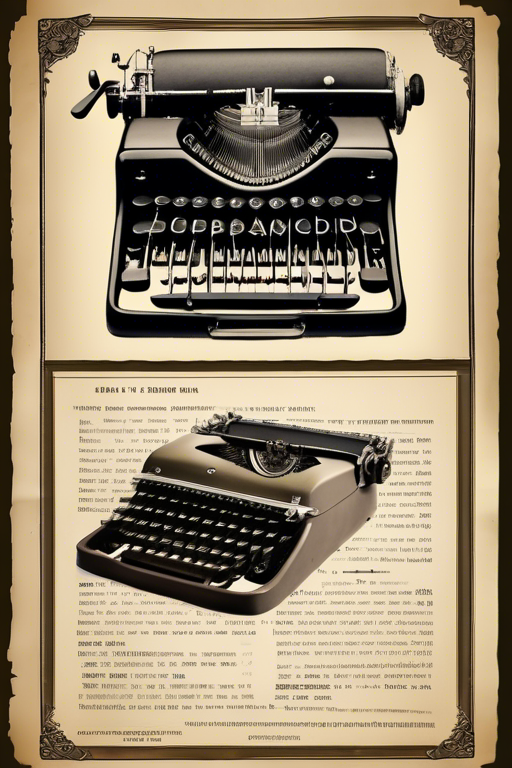

In [16]:
from IPython.display import Image
Image('/content/Poster_1_Lost_Time.png')

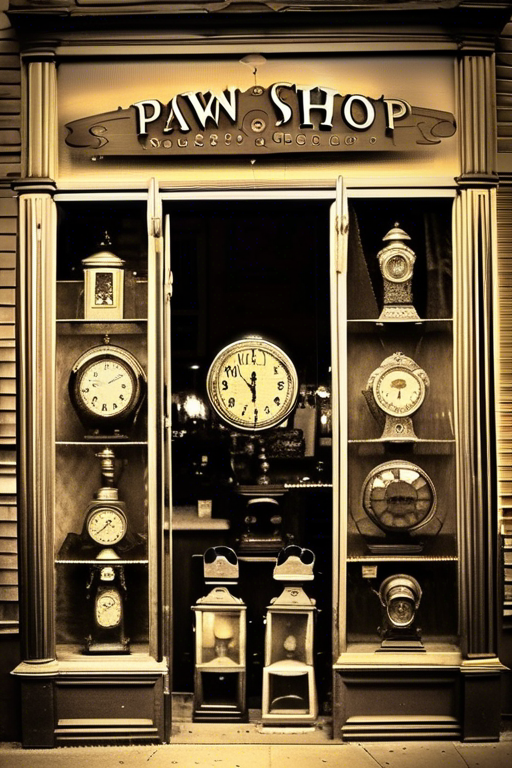

In [17]:
from IPython.display import Image
Image('/content/Poster_2_Collective.png')

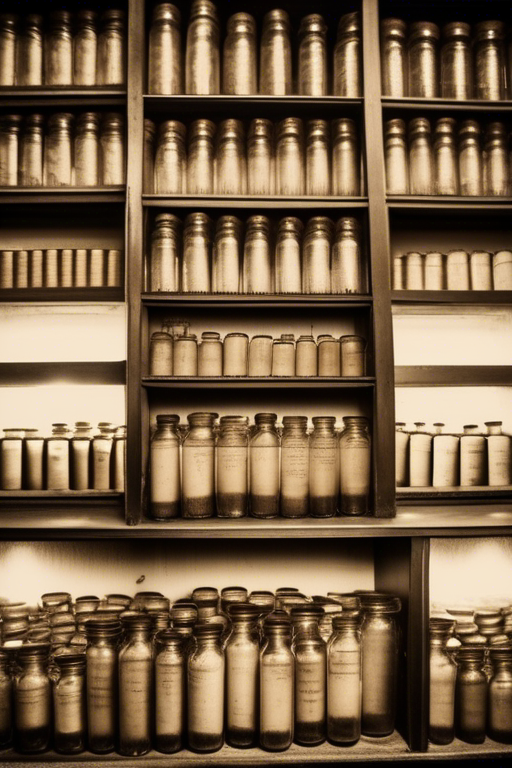

In [18]:
from IPython.display import Image
Image('/content/Poster_3_Sanctuary.png')